In [39]:
!pip install lightgbm xgboost openpyxl -q

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
from sklearn.metrics import mean_absolute_percentage_error
from lightgbm import LGBMRegressor
import lightgbm as lgb

warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:.4f}'.format

In [41]:
pgcb_raw = pd.read_excel('PGCB_date_power_demand.xlsx')
pgcb_raw['datetime'] = pd.to_datetime(pgcb_raw['datetime'])
pgcb_raw = pgcb_raw.sort_values('datetime').reset_index(drop=True)
print(f"PGCB Raw Shape: {pgcb_raw.shape}")

PGCB Raw Shape: (92650, 15)


In [42]:
pgcb_raw = pgcb_raw.sort_values(['datetime', 'demand_mw'], ascending=[True, False])
pgcb_raw = pgcb_raw.drop_duplicates(subset='datetime', keep='first')
pgcb_raw = pgcb_raw.set_index('datetime')

full_idx = pd.date_range(pgcb_raw.index.min(), pgcb_raw.index.max(), freq='h')
pgcb_raw = pgcb_raw.reindex(full_idx)
pgcb_raw.index.name = 'datetime'
print(pgcb_raw.shape)
print(pgcb_raw['demand_mw'].isna().sum(), "missing after reindex")

(89101, 14)
1055 missing after reindex


In [43]:
q1 = pgcb_raw['demand_mw'].quantile(0.25)
q3 = pgcb_raw['demand_mw'].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 3 * iqr
lower_fence = max(q1 - 3 * iqr, 0)

spike_mask = (pgcb_raw['demand_mw'] > upper_fence) | (pgcb_raw['demand_mw'] < lower_fence)
print(f"Flagged anomalies: {spike_mask.sum()}")
print(f"IQR bounds: {lower_fence:.1f} MW - {upper_fence:.1f} MW")

pgcb_raw.loc[spike_mask, 'demand_mw'] = np.nan
pgcb_raw['demand_mw'] = pgcb_raw['demand_mw'].interpolate(method='time')
pgcb_raw['demand_mw'] = pgcb_raw['demand_mw'].fillna(method='bfill').fillna(method='ffill')

for col in ['generation_mw', 'gas', 'coal', 'liquid_fuel', 'hydro', 'solar', 'wind',
            'india_bheramara_hvdc', 'india_tripura', 'india_adani', 'nepal', 'load_shedding']:
    if col in pgcb_raw.columns:
        pgcb_raw[col] = pgcb_raw[col].interpolate(method='time').fillna(method='bfill').fillna(method='ffill')

pgcb_raw['demand_mw'].describe()

Flagged anomalies: 6
IQR bounds: 0.0 MW - 22054.0 MW


,demand_mw
count,89101.0000
mean,8744.3190
std,2613.8023
min,6.0000
25%,6734.0000
50%,8349.0000
75%,10560.0000
max,20587.0000


In [44]:
weather_raw = pd.read_excel('weather_data.xlsx', skiprows=3)
weather_raw = weather_raw.rename(columns={
    'time': 'datetime',
    'temperature_2m (°C)': 'temp_c',
    'relative_humidity_2m (%)': 'humidity',
    'apparent_temperature (°C)': 'apparent_temp',
    'precipitation (mm)': 'precipitation',
    'dew_point_2m (°C)': 'dew_point',
    'soil_temperature_0_to_7cm (°C)': 'soil_temp',
    'wind_direction_10m (°)': 'wind_direction',
    'cloud_cover (%)': 'cloud_cover',
    'sunshine_duration (s)': 'sunshine_duration'
})
weather_raw['datetime'] = pd.to_datetime(weather_raw['datetime'])
weather_raw = weather_raw.set_index('datetime')
weather_raw = weather_raw[~weather_raw.index.duplicated(keep='first')]
print(f"Weather Raw Shape: {weather_raw.shape}")

Weather Raw Shape: (107304, 9)


In [45]:
eco_raw = pd.read_csv('economic_full_1.csv')

eco_indicators = {
    'gdp_per_capita_ppp': 'GDP per capita, PPP (current international $)',
    'urban_population': 'Urban population',
    'gdp_usd': 'GDP (current US$)',
    'population_total': 'Population, total'
}

years = [str(y) for y in range(2014, 2026)]
eco_annual = {}

for feat_name, indicator in eco_indicators.items():
    row = eco_raw[eco_raw['Indicator Name'] == indicator]
    if len(row) > 0:
        vals = row[years].values[0]
        eco_annual[feat_name] = dict(zip([int(y) for y in years], vals))

eco_df = pd.DataFrame(eco_annual).reset_index()
eco_df.columns = ['year'] + list(eco_annual.keys())
eco_df['year'] = eco_df['year'].astype(int)
eco_df = eco_df.fillna(method='ffill').fillna(method='bfill')
print(eco_df[['year','gdp_per_capita_ppp','urban_population']].to_string())

    year  gdp_per_capita_ppp  urban_population
0   2014           3972.5065     46116983.0000
1   2015           4212.2358     47081010.0000
2   2016           4579.1323     48043194.0000
3   2017           4882.6069     48982779.0000
4   2018           5490.1588     49903270.0000
5   2019           6047.1240     50830886.0000
6   2020           6640.5844     51746778.0000
7   2021           7441.0691     52643565.0000
8   2022           8450.5490     53650523.0000
9   2023           9147.7775     55140091.0000
10  2024           9646.7698     56717264.0000
11  2025           9646.7698     56717264.0000


In [46]:
df = pgcb_raw[['demand_mw', 'generation_mw', 'load_shedding', 'gas', 'coal',
                'liquid_fuel', 'hydro', 'solar', 'wind']].copy()

df = df.join(weather_raw[['temp_c', 'humidity', 'apparent_temp', 'precipitation',
                           'dew_point', 'cloud_cover', 'sunshine_duration']], how='left')

df['year'] = df.index.year
df = df.merge(eco_df, on='year', how='left')
df = df.set_index(pgcb_raw.index) if not isinstance(df.index, pd.DatetimeIndex) else df

for wcol in ['temp_c', 'humidity', 'apparent_temp', 'precipitation', 'dew_point', 'cloud_cover', 'sunshine_duration']:
    df[wcol] = df[wcol].interpolate(method='time').fillna(method='bfill').fillna(method='ffill')

print(df.shape)
print(df.isna().sum()[df.isna().sum() > 0])

(89101, 21)
Series([], dtype: int64)


In [47]:
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['day_of_year'] = df.index.dayofyear
df['week_of_year'] = df.index.isocalendar().week.astype(int)
df['is_weekend'] = (df.index.dayofweek >= 5).astype(int)
df['quarter'] = df.index.quarter
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

In [48]:
lag_hours = [1, 2, 3, 6, 12, 24, 48, 72, 168, 336]
for lag in lag_hours:
    df[f'lag_{lag}h'] = df['demand_mw'].shift(lag)

for offset in [24, 168]:
    for delta in [-1, 0, 1]:
        shift_val = offset + delta
        df[f'lag_{shift_val}h'] = df['demand_mw'].shift(shift_val)

In [49]:
rolling_windows = [3, 6, 12, 24, 48, 168]
for w in rolling_windows:
    shifted = df['demand_mw'].shift(1)
    df[f'roll_mean_{w}h'] = shifted.rolling(w, min_periods=1).mean()
    df[f'roll_std_{w}h'] = shifted.rolling(w, min_periods=1).std()
    df[f'roll_max_{w}h'] = shifted.rolling(w, min_periods=1).max()
    df[f'roll_min_{w}h'] = shifted.rolling(w, min_periods=1).min()

df['roll_mean_24h_7d'] = df['demand_mw'].shift(1).rolling(168, min_periods=1).mean()
df['demand_diff_1h'] = df['demand_mw'].shift(1).diff(1)
df['demand_diff_24h'] = df['demand_mw'].shift(1).diff(24)

In [50]:
df['target'] = df['demand_mw'].shift(-1)
df = df.dropna(subset=['target'])
df = df.dropna(subset=[c for c in df.columns if c.startswith('lag_')])

print(f"Final dataset: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")

Final dataset: (88764, 76)
Date range: 2015-05-03 00:00:00 to 2025-06-17 11:00:00


In [51]:
test_mask = df.index.year == 2024
train_mask = df.index.year < 2024

features = [c for c in df.columns if c not in ['target', 'demand_mw', 'remarks']]
features = [c for c in features if c in df.columns]

X_train = df.loc[train_mask, features]
y_train = df.loc[train_mask, 'target']
X_test = df.loc[test_mask, features]
y_test = df.loc[test_mask, 'target']

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train period: {X_train.index.min()} - {X_train.index.max()}")
print(f"Test period:  {X_test.index.min()} - {X_test.index.max()}")

Train: (75960, 74), Test: (8784, 74)
Train period: 2015-05-03 00:00:00 - 2023-12-31 23:00:00
Test period:  2024-01-01 00:00:00 - 2024-12-31 23:00:00


In [52]:
model = LGBMRegressor(
    n_estimators=1500,
    learning_rate=0.05,
    num_leaves=127,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(200)]
)

print("Best iteration:", model.best_iteration_)

[200]	valid_0's l2: 297143
Best iteration: 117


In [53]:
y_pred = model.predict(X_test)
y_pred = np.clip(y_pred, 0, None)

mape = mean_absolute_percentage_error(y_test, y_pred) * 100
mae = np.mean(np.abs(y_test - y_pred))
rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))

print(f"Test MAPE : {mape:.4f}%")
print(f"Test MAE  : {mae:.2f} MW")
print(f"Test RMSE : {rmse:.2f} MW")
print(f"Mean actual demand (2024): {y_test.mean():.2f} MW")
print(f"MAPE interpretation: on average, predictions are off by {mape:.2f}% of actual demand")

Test MAPE : 4.4033%
Test MAE  : 265.98 MW
Test RMSE : 535.42 MW
Mean actual demand (2024): 11384.90 MW
MAPE interpretation: on average, predictions are off by 4.40% of actual demand


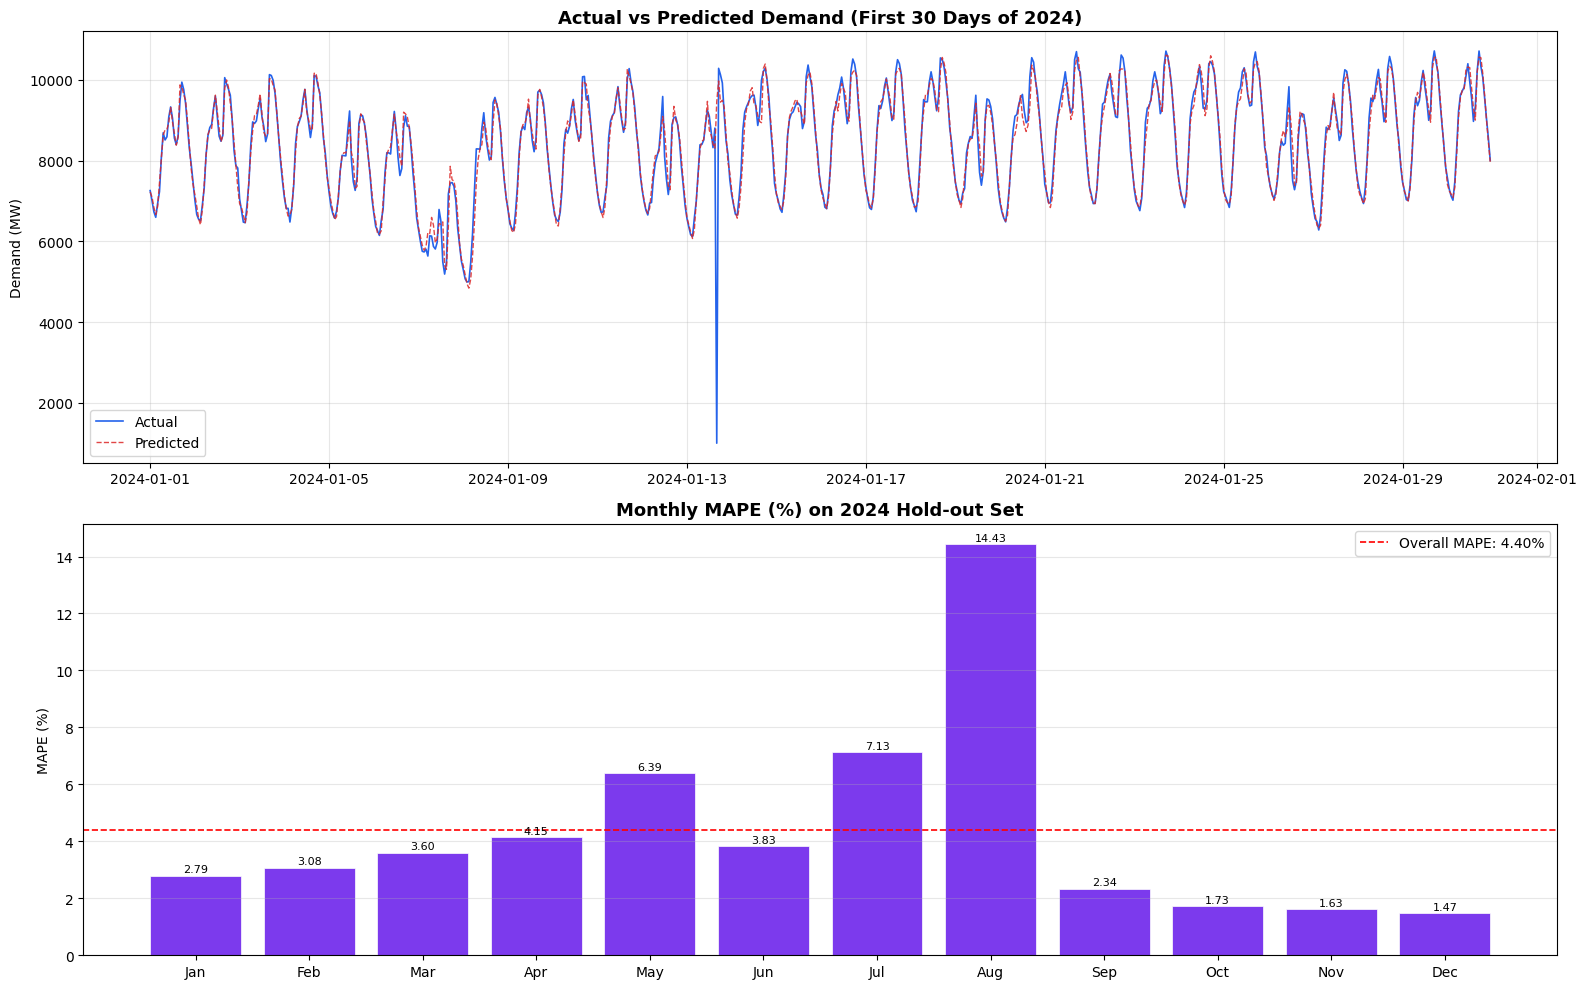

In [54]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

sample = pd.DataFrame({'actual': y_test.values, 'predicted': y_pred}, index=y_test.index)
sample_week = sample.iloc[:24*30]

axes[0].plot(sample_week.index, sample_week['actual'], label='Actual', color='#2563eb', linewidth=1.2)
axes[0].plot(sample_week.index, sample_week['predicted'], label='Predicted', color='#dc2626', linewidth=1.0, linestyle='--', alpha=0.85)
axes[0].set_title('Actual vs Predicted Demand (First 30 Days of 2024)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Demand (MW)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

monthly_mape = []
months = sorted(sample.index.month.unique())
for m in months:
    mask = sample.index.month == m
    m_mape = mean_absolute_percentage_error(sample.loc[mask, 'actual'], sample.loc[mask, 'predicted']) * 100
    monthly_mape.append((m, m_mape))

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
m_vals = [x[0] for x in monthly_mape]
mape_vals = [x[1] for x in monthly_mape]
bars = axes[1].bar([month_names[m-1] for m in m_vals], mape_vals, color='#7c3aed', edgecolor='white', linewidth=0.5)
axes[1].set_title('Monthly MAPE (%) on 2024 Hold-out Set', fontsize=13, fontweight='bold')
axes[1].set_ylabel('MAPE (%)')
axes[1].axhline(mape, color='red', linestyle='--', linewidth=1.2, label=f'Overall MAPE: {mape:.2f}%')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, mape_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{val:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('predictions_2024.png', dpi=150, bbox_inches='tight')
plt.show()

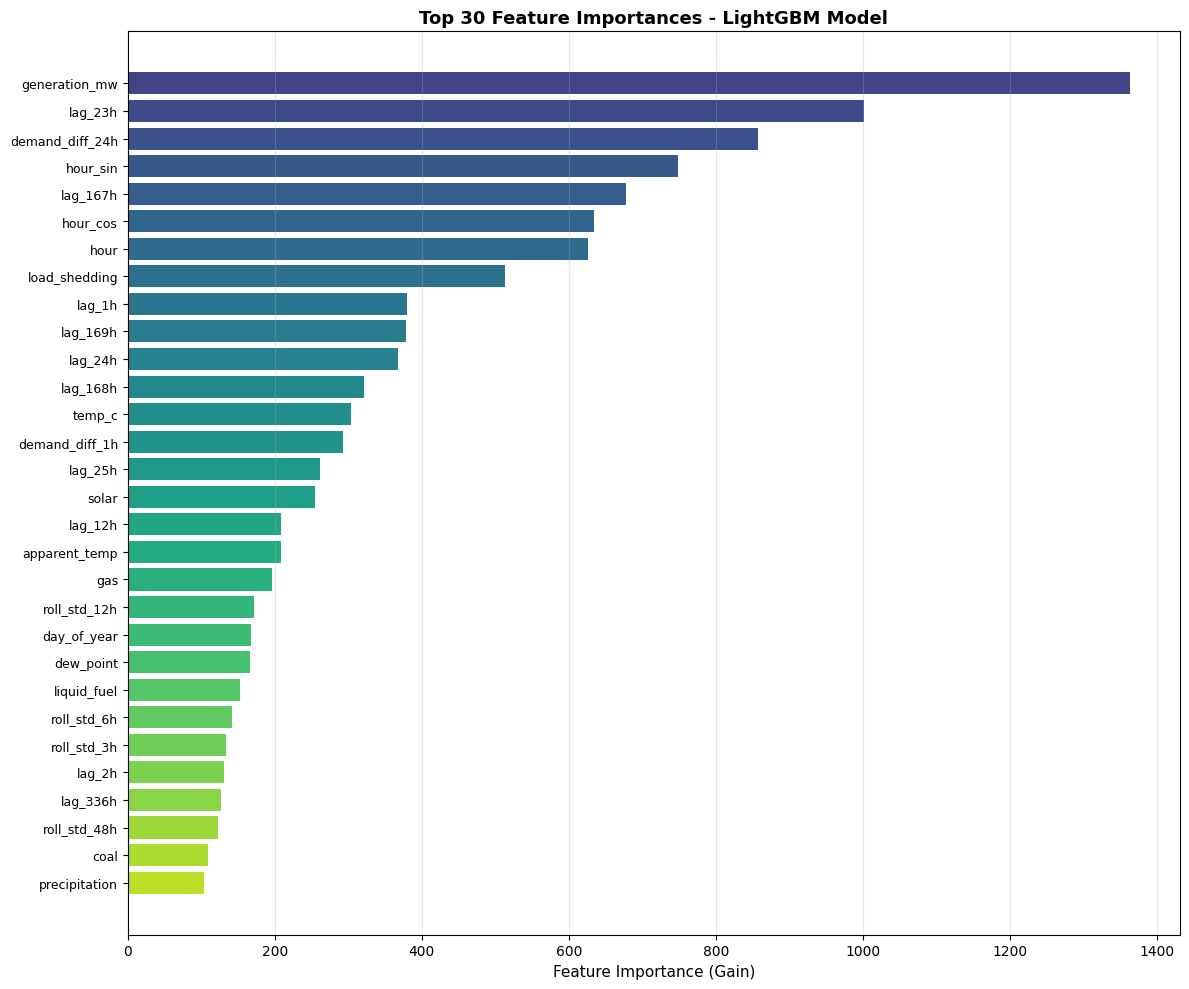


Top 15 features:
generation_mw      1363
lag_23h            1002
demand_diff_24h     857
hour_sin            748
lag_167h            677
hour_cos            634
hour                626
load_shedding       513
lag_1h              380
lag_169h            379
lag_24h             368
lag_168h            321
temp_c              304
demand_diff_1h      293
lag_25h             262


In [55]:
feat_imp = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
top_n = 30

fig, ax = plt.subplots(figsize=(12, 10))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, top_n))
bars = ax.barh(range(top_n), feat_imp.iloc[:top_n].values[::-1], color=colors[::-1])
ax.set_yticks(range(top_n))
ax.set_yticklabels(feat_imp.index[:top_n].tolist()[::-1], fontsize=9)
ax.set_xlabel('Feature Importance (Gain)', fontsize=11)
ax.set_title('Top 30 Feature Importances - LightGBM Model', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 15 features:")
print(feat_imp.head(15).to_string())

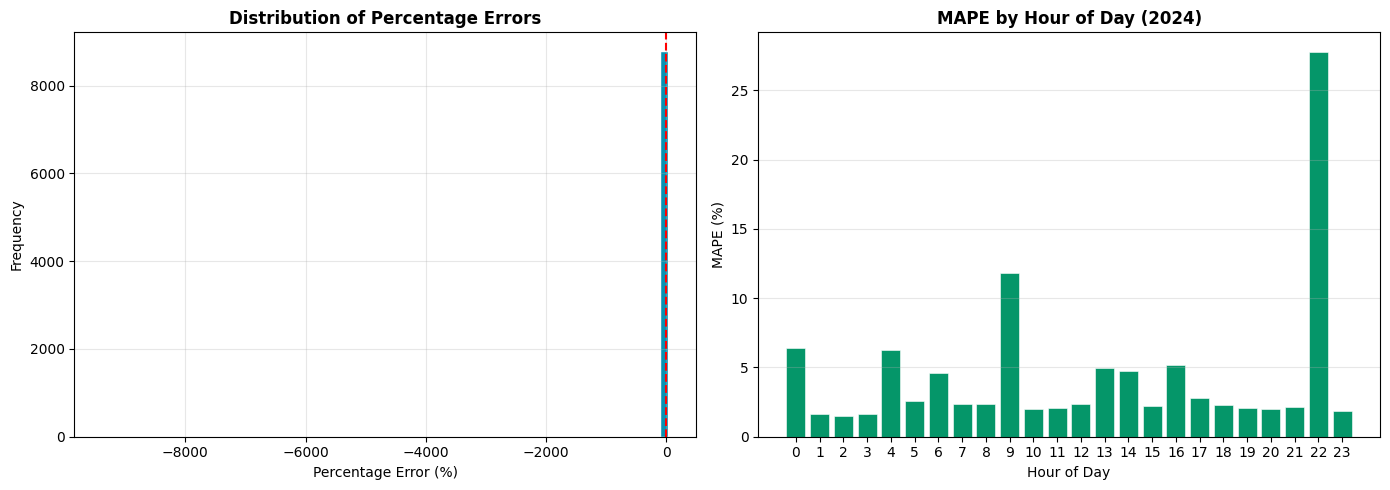

In [56]:
residuals = y_test.values - y_pred
pct_errors = (residuals / y_test.values) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(pct_errors, bins=80, color='#0891b2', edgecolor='white', linewidth=0.3)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Percentage Error (%)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Percentage Errors', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

hour_mape = []
for h in range(24):
    mask = y_test.index.hour == h
    if mask.sum() > 0:
        hm = mean_absolute_percentage_error(y_test[mask], y_pred[mask]) * 100
        hour_mape.append((h, hm))

h_vals = [x[0] for x in hour_mape]
hm_vals = [x[1] for x in hour_mape]
axes[1].bar(h_vals, hm_vals, color='#059669', edgecolor='white', linewidth=0.4)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('MAPE (%)')
axes[1].set_title('MAPE by Hour of Day (2024)', fontsize=12, fontweight='bold')
axes[1].set_xticks(range(24))
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [57]:
summary = {
    'model': 'LightGBM Regressor',
    'test_year': 2024,
    'test_mape_pct': round(mape, 4),
    'test_mae_mw': round(float(mae), 2),
    'test_rmse_mw': round(float(rmse), 2),
    'n_features': len(features),
    'train_samples': int(X_train.shape[0]),
    'test_samples': int(X_test.shape[0]),
    'best_iteration': int(model.best_iteration_)
}


print("REPORT")

for k, v in summary.items():
    print(f"  {k:<25} {v}")

print(f"\nTop 5 demand drivers:")
for feat, score in feat_imp.head(5).items():
    print(f"  {feat:<30} importance={score:.0f}")

REPORT
  model                     LightGBM Regressor
  test_year                 2024
  test_mape_pct             4.4033
  test_mae_mw               265.98
  test_rmse_mw              535.42
  n_features                74
  train_samples             75960
  test_samples              8784
  best_iteration            117

Top 5 demand drivers:
  generation_mw                  importance=1363
  lag_23h                        importance=1002
  demand_diff_24h                importance=857
  hour_sin                       importance=748
  lag_167h                       importance=677
